# Loading Dataset and CNN
*Rolando A. Pula*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (grayscale, resize, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Before you run this notebook:** download the Kaggle "Dogs vs. Cats" dataset (e.g. `https://www.kaggle.com/c/dogs-vs-cats/data` or the mirrored `salader/dogs-vs-cats` dataset on Kaggle) and unzip it so you have two folders, `Dog/` and `Cat/`, each full of `.jpg` images. Then set `DATADIR` below to point at the parent folder that contains `Dog/` and `Cat/`.

## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [24]:
# Run this once if the packages below aren't already installed.
# %pip install opencv-python numpy matplotlib tensorflow

## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [27]:
import zipfile
import os

# Path to the zip file in Google Drive

zip_file_path = '/content/drive/MyDrive/PetImages.zip'

# Destination directory to unzip the files
destination_dir = '/content/'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# Update DATADIR to point to this unzipped location

Unzipped '/content/drive/MyDrive/PetImages.zip' to '/content/'


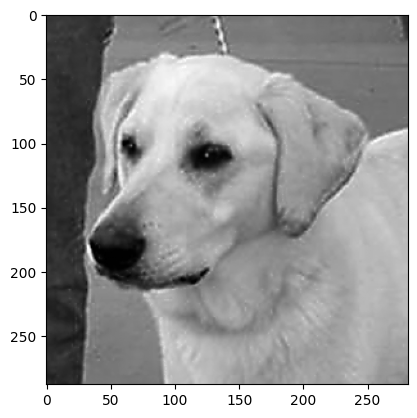

In [28]:
DATADIR = "/content/PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
# this is the directory of your datasets
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)  # path to cats or dogs dir
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # reading the image in the path and transforming it into an array
        # cv2.IMREAD_GRAYSCALE converts the image to grayscale so the CNN only has
        # to learn from one color channel instead of three (faster, smaller model)

        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

## Image Inspection

In [29]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[ 78  78  77 ...  77  75  75]
 [ 76  75  75 ...  71  70  69]
 [ 74  73  72 ...  67  65  65]
 ...
 [ 60  61  61 ... 145 144 145]
 [ 64  66  66 ... 143 143 144]
 [ 69  68  67 ... 142 142 143]]
(288, 282)


## Image Resizing

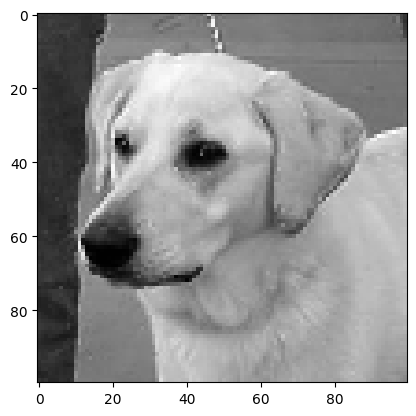

In [30]:
IMG_SIZE = 100  # initializing variable "IMG_SIZE" as 100

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

## Assigning Training Data

In [31]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)  # path to cats or dogs dir
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()

## Checking the Number of Training Data

In [32]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [33]:
import random
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

0
1
1
1
1
0
0
1
1
0


## Assigning Variables for Features and Labels

In [34]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # 1 is for grayscale
y = np.array(y)  # Keras expects the labels as an array too

## Using the Pickle Module

In [35]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [36]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[ 68],
        [ 68],
        [ 68],
        ...,
        [ 22],
        [ 23],
        [ 18]],

       [[ 68],
        [ 68],
        [ 68],
        ...,
        [ 15],
        [ 16],
        [ 13]],

       [[ 68],
        [ 68],
        [ 68],
        ...,
        [  8],
        [  8],
        [  7]],

       ...,

       [[190],
        [190],
        [188],
        ...,
        [ 45],
        [ 51],
        [ 46]],

       [[191],
        [190],
        [188],
        ...,
        [ 46],
        [ 52],
        [ 46]],

       [[191],
        [190],
        [188],
        ...,
        [ 46],
        [ 52],
        [ 46]]], dtype=uint8)

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

## Building, Compiling, and Training the CNN

`X = X/255.0` normalizes the pixel values (0-255) down to the 0-1 range, which helps the network train faster and more stably.

> Training for the full 200 epochs on the whole dataset can take a long time on CPU. Reduce `epochs` (e.g. to 10) for a quick test run, and increase it back up once you know the pipeline works.

In [44]:
X = X / 255.0

model = Sequential()
model.add(Input(shape=X.shape[1:]))

model.add(Conv2D(2, (3, 3)))
#model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(64))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])



In [45]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 98, 98, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,665 (8.28 MB)

 Trainable params: 2,171,665 (8.28 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(X, y, batch_size=128, epochs=5, validation_split=0.2)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 284ms/step - accuracy: 0.5749 - loss: 1.4386 - val_accuracy: 0.5272 - val_loss: 0.9356
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 250ms/step - accuracy: 0.6518 - loss: 0.6379 - val_accuracy: 0.6426 - val_loss: 0.6333
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - accuracy: 0.6880 - loss: 0.5849 - val_accuracy: 0.6948 - val_loss: 0.5858
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - accuracy: 0.7103 - loss: 0.5578 - val_accuracy: 0.6750 - val_loss: 0.5989
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 250ms/step - accuracy: 0.7340 - loss: 0.5278 - val_accuracy: 0.6750 - val_loss: 0.6110


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 98, 98, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 98, 98, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 49, 49, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 19208)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,229,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,688,565 (14.07 MB)

 Trainable params: 1,229,521 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,459,044 (9.38 MB)

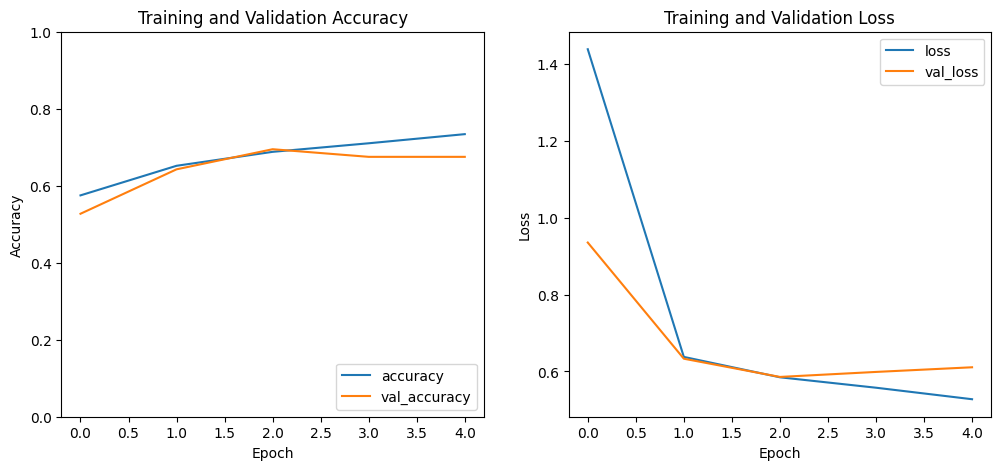

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step

Confusion Matrix:
[[ 7206  5293]
 [ 1481 11017]]


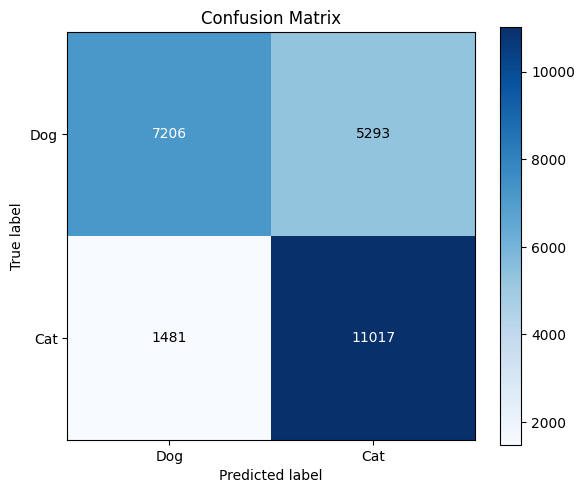

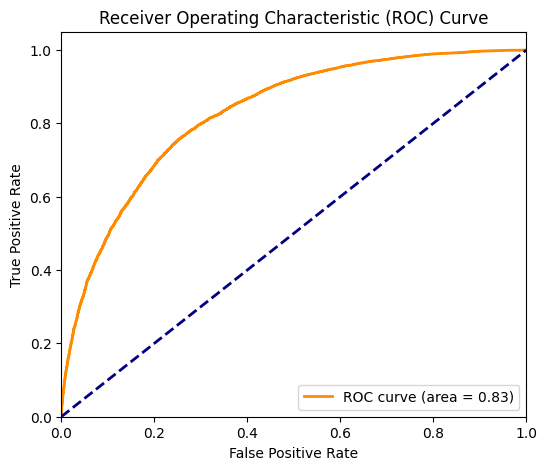

In [40]:
model.summary()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np # numpy is already imported as np earlier

# Plot training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Get predictions for confusion matrix and ROC
y_pred_proba = model.predict(X).ravel() # .ravel() to flatten to 1D array
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y)))
CATEGORIES = ["Dog", "Cat"]
plt.xticks(tick_marks, CATEGORIES)
plt.yticks(tick_marks, CATEGORIES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
fmt = 'd'
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], fmt),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [41]:
import tensorflow as tf

# Define the filename for your model
model_filename = 'dog_cat_classifier.keras' # .keras is the recommended extension for Keras models

# Save the model
model.save(model_filename)
print(f"Model saved to {model_filename}")

# To load the model later (you can do this in a new session or script)
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# You can then use the loaded_model for predictions or further evaluation
# For example, let's make predictions with the loaded model and compare
loaded_model_predictions = loaded_model.predict(X)
print("\nExample predictions from loaded model:")
print(loaded_model_predictions[:5])


Model saved to dog_cat_classifier.keras
Model loaded from dog_cat_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step

Example predictions from loaded model:
[[0.3672581 ]
 [0.85642064]
 [0.7617244 ]
 [0.64377785]
 [0.82900167]]


## Prediction Inference

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predictions for the test samples:
Sample 1: Predicted Class = Dog (Probability: 36.73%) 
Sample 2: Predicted Class = Cat (Probability: 85.64%) 
Sample 3: Predicted Class = Cat (Probability: 76.17%) 
Sample 4: Predicted Class = Cat (Probability: 64.38%) 
Sample 5: Predicted Class = Cat (Probability: 82.90%) 


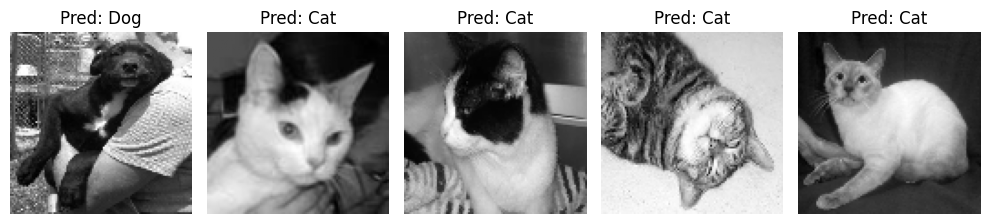

In [42]:
# Select a small subset of data for inference (e.g., the first 5 samples)
# In a real scenario, this would be entirely new, unseen test data.
test_samples = X[:5]

# Make predictions using the loaded model
inference_predictions = loaded_model.predict(test_samples)

print("Predictions for the test samples:")
for i, prediction in enumerate(inference_predictions):
    # Assuming binary classification with sigmoid output, values close to 1 are 'Cat', close to 0 are 'Dog'
    predicted_class = 'Cat' if prediction[0] > 0.5 else 'Dog'
    probability = prediction[0] * 100
    print(f"Sample {i+1}: Predicted Class = {predicted_class} (Probability: {probability:.2f}%) ")

# Optionally, display the images and their predictions
plt.figure(figsize=(10, 4))
for i in range(min(5, len(test_samples))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_samples[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    predicted_class = 'Cat' if inference_predictions[i][0] > 0.5 else 'Dog'
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()

---
---

# PART 2 — ACTIVITY ANSWERS

**Rachelle Mae M. Ortiz** — Doctor of Information Technology, T.I.P. Quezon City

Every example below uses the **same Dogs vs. Cats dataset** loaded in Part 1, so the answers are
demonstrated on our own data rather than on a generic sample image.

**Prerequisites:** run Part 1 first, at least up to the cell that sets `DATADIR` and `IMG_SIZE`.
The helper below re-reads single images straight from `DATADIR`, so `training_data` does not need to
be built for Questions 1-4.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Falls back to the Part 1 values if those cells have not been run in this session.
DATADIR    = globals().get("DATADIR", "/content/PetImages")
CATEGORIES = globals().get("CATEGORIES", ["Dog", "Cat"])
IMG_SIZE   = globals().get("IMG_SIZE", 100)


def load_sample(category="Dog", index=0, color=True, size=256):
    """Read one usable image straight out of DATADIR/<category>.

    A handful of files in the Kaggle set are corrupted, so unreadable files are skipped
    rather than counted.
    """
    path  = os.path.join(DATADIR, category)
    flag  = cv2.IMREAD_COLOR if color else cv2.IMREAD_GRAYSCALE
    found = 0
    for fn in sorted(os.listdir(path)):
        arr = cv2.imread(os.path.join(path, fn), flag)
        if arr is None:
            continue
        if found == index:
            if color:
                arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)   # OpenCV is BGR, matplotlib is RGB
            return cv2.resize(arr, (size, size)), fn
        found += 1
    raise FileNotFoundError(f"No readable image found in {path}")


dog, dog_name = load_sample("Dog", 0)
cat, cat_name = load_sample("Cat", 0)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(dog); ax[0].set_title(f"Dog/{dog_name}", fontsize=10); ax[0].axis("off")
ax[1].imshow(cat); ax[1].set_title(f"Cat/{cat_name}", fontsize=10); ax[1].axis("off")
plt.tight_layout(); plt.show()

print("Working image shape:", dog.shape, "| dtype:", dog.dtype)

### Auto-saving every figure

Running the notebook displays each figure inline, but it does **not** create image files on its own.
The cell below turns on automatic saving: from this point onward, every `plt.show()` also writes a
PNG into an `activity_figures/` folder, so the figures can be dropped straight into a Word document
or a slide deck without taking manual screenshots.

Set `SAVE_FIGURES = False` if you only want the inline display.

In [ ]:
import os
import matplotlib.pyplot as plt

SAVE_FIGURES = True
FIG_DIR      = "activity_figures"
FIG_DPI      = 150

os.makedirs(FIG_DIR, exist_ok=True)
_fig_count = {"n": 0}

if not hasattr(plt, "_original_show"):
    plt._original_show = plt.show          # keep a handle so this cell is safe to re-run


def _show_and_save(*args, **kwargs):
    """Save the current figure to FIG_DIR, then display it as usual."""
    if SAVE_FIGURES:
        _fig_count["n"] += 1
        fname = os.path.join(FIG_DIR, f"figure_{_fig_count['n']:02d}.png")
        try:
            plt.savefig(fname, dpi=FIG_DPI, bbox_inches="tight")
            print(f"[saved] {fname}")
        except Exception as e:
            print(f"[save failed] {e}")
    plt._original_show(*args, **kwargs)


plt.show = _show_and_save
print(f"Figure auto-save is ON. Files will be written to ./{FIG_DIR}/")
print("Re-run the image-loading cell above if you also want that preview saved.")

---
## Question 1 — Design a linear filter to brighten / darken an image (10 pts)

### Concept

Brightness is controlled by an **affine point operation**, the simplest linear filter:

$$g(x,y) = a \cdot f(x,y) + b$$

- `a` = **gain / contrast multiplier** (multiplicative term)
- `b` = **bias / brightness offset** (additive term)

| Goal | Setting | Effect on the histogram |
|---|---|---|
| Brighten | `b > 0` (e.g. `+60`) or `a > 1` (e.g. `1.5`) | shifts / stretches toward 255 |
| Darken | `b < 0` (e.g. `-60`) or `0 < a < 1` (e.g. `0.5`) | shifts / compresses toward 0 |
| Identity | `a = 1, b = 0` | unchanged |

### Written as a convolution kernel

The multiplicative part is a **scaled identity kernel** — the centre tap carries the gain and every
other tap is zero. This proves it is genuinely a *linear filter*: no neighbouring pixel is mixed in,
so there is no blurring or sharpening, only a per-pixel scaling.

```
Brighten (a = 1.5)        Darken (a = 0.5)
[ 0    0    0 ]           [ 0    0    0 ]
[ 0   1.5   0 ]           [ 0   0.5   0 ]
[ 0    0    0 ]           [ 0    0    0 ]
```

In [ ]:
def linear_brightness(im, a=1.0, b=0):
    """g = a*f + b, clipped back into the valid 8-bit range."""
    return np.clip(im.astype(np.float32) * a + b, 0, 255).astype(np.uint8)


def gain_kernel(a):
    """3x3 scaled identity kernel: convolving with it multiplies every pixel by a."""
    k = np.zeros((3, 3), np.float32)
    k[1, 1] = a
    return k


print("Brighten kernel (a = 1.5):\n", gain_kernel(1.5))
print("\nDarken kernel (a = 0.5):\n", gain_kernel(0.5))

# Proof that the kernel form and the arithmetic form are the same operation
assert np.allclose(cv2.filter2D(dog, -1, gain_kernel(1.0)), dog)
print("\nIdentity kernel (a = 1.0) returns the image unchanged - confirmed.")

In [ ]:
bright_bias = linear_brightness(dog, a=1.0, b=+60)      # additive
dark_bias   = linear_brightness(dog, a=1.0, b=-60)
bright_gain = cv2.filter2D(dog, -1, gain_kernel(1.5))  # multiplicative, via convolution
dark_gain   = cv2.filter2D(dog, -1, gain_kernel(0.5))

panels = [(dog,         "Original (Dogs vs Cats)"),
          (bright_bias, "Brighten: b = +60 (bias)"),
          (dark_bias,   "Darken: b = -60 (bias)"),
          (bright_gain, "Brighten: a = 1.5 (gain kernel)"),
          (dark_gain,   "Darken: a = 0.5 (gain kernel)")]

fig, ax = plt.subplots(1, 5, figsize=(19, 4.2))
for a_, (im, t) in zip(ax, panels):
    a_.imshow(im); a_.set_title(t, fontsize=10); a_.axis("off")
plt.suptitle("Q1: Brightening and darkening a training image", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# Evidence that this is a LINEAR POINT operation: the histogram SHIFTS,
# it does not change shape. That is the signature of g = a*f + b.
fig, ax = plt.subplots(1, 4, figsize=(17, 3.2))
for a_, (im, t) in zip(ax, [(dog, "Original"), (bright_bias, "b = +60"),
                            (dark_bias, "b = -60"), (bright_gain, "a = 1.5")]):
    a_.hist(cv2.cvtColor(im, cv2.COLOR_RGB2GRAY).ravel(), bins=64, range=(0, 255))
    a_.set_title(t, fontsize=10); a_.set_xlim(0, 255); a_.set_xlabel("intensity")
plt.tight_layout(); plt.show()

for im, t in [(dog, "Original"), (bright_bias, "b = +60"), (dark_bias, "b = -60")]:
    print(f"{t:<12} mean = {im.mean():6.2f}   std = {im.std():6.2f}")

In [ ]:
# Why this matters for OUR classifier: the same filter is a brightness AUGMENTATION.
# The label does not change when lighting changes, so training on brightness-varied
# copies makes the CNN robust to photos taken under different lighting.
gray = cv2.cvtColor(dog, cv2.COLOR_RGB2GRAY)
gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))          # same preprocessing as Part 1

variants = [linear_brightness(gray, 1.0, b) for b in (-60, -30, 0, 30, 60)]

fig, ax = plt.subplots(1, 5, figsize=(15, 3.4))
for a_, (im, b) in zip(ax, zip(variants, (-60, -30, 0, 30, 60))):
    a_.imshow(im, cmap="gray"); a_.set_title(f"b = {b:+d}", fontsize=10); a_.axis("off")
plt.suptitle(f"Brightness augmentation at the notebook's {IMG_SIZE}x{IMG_SIZE} grayscale size", y=1.04)
plt.tight_layout(); plt.show()

### Design considerations

1. **Clipping is destructive.** Values pushed past 255 or below 0 saturate, and those pixels can never
   be recovered — the operation stops being invertible. Keep `b` moderate.
2. **Gain and bias are not interchangeable.** A bias shifts every pixel equally and *flattens* contrast
   in the highlights. A gain scales proportionally, so it brightens highlights more than shadows and
   *increases* contrast. Combining both (`a = 1.2, b = 20`) gives finer control.
3. **Colour images.** Applying the same `a` and `b` to R, G and B preserves hue. To change brightness
   without touching saturation, convert to HSV or LAB and modify only the V or L channel. Our pipeline
   is grayscale, so this does not arise here.
4. **Gamma correction** (`g = 255(f/255)^γ`) matches human perception better but is **non-linear**, so
   it falls outside what this question asks for.

---
## Question 2 — Design a linear filter to remove wrinkles / blemishes (10 pts)

### Concept

Wrinkles, blemishes, pores, speckle and sensor noise are all **high spatial frequencies** — small,
fast-changing detail. Removing them means applying a **low-pass (smoothing) filter**: a convolution
kernel whose weights are non-negative and **sum to 1**, so each pixel is replaced by a weighted
average of its neighbourhood.

Our dataset is animal photos rather than faces, so the equivalent artifacts are **fur speckle, JPEG
noise and dust spots**. The filter design and the mathematics are identical — only the subject changes.
We add controlled artifacts to a real training image so the improvement is measurable against a clean
reference.

In [ ]:
rng = np.random.default_rng(3)

# Realistic degradation: Gaussian sensor noise + salt-and-pepper specks + fine scratches
noisy = dog.astype(np.float32) + rng.normal(0, 16, dog.shape)

mask = rng.random(dog.shape[:2])
noisy[mask < 0.008] = 0                    # pepper
noisy[mask > 0.992] = 255                  # salt

scratch = np.zeros(dog.shape[:2], np.float32)
for _ in range(45):
    x, y = rng.integers(20, 236), rng.integers(20, 236)
    L, ang = int(rng.integers(5, 16)), rng.uniform(0, np.pi)
    cv2.line(scratch, (x, y),
             (int(x + L*np.cos(ang)), int(y + L*np.sin(ang))),
             float(rng.uniform(-35, -18)), 1)

degraded = np.clip(noisy + scratch[..., None], 0, 255).astype(np.uint8)
print("Synthetic blemishes, speckle and noise added to the training image.")

In [ ]:
# ---- Option A: mean (box) filter - every weight equal ----
box5  = np.ones((5, 5), np.float32) / 25.0
mean5 = cv2.filter2D(degraded, -1, box5)

# ---- Option B: Gaussian filter - weights fall off with distance ----
gauss = cv2.GaussianBlur(degraded, (9, 9), 2.5)

# ---- Option C: frequency separation - blur the base, add back only PART of the detail ----
base   = cv2.GaussianBlur(degraded, (9, 9), 2.5).astype(np.float32)
detail = degraded.astype(np.float32) - base
k      = 0.35                    # k=0 full blur, k=1 original, k>1 becomes unsharp masking
soft   = np.clip(base + k * detail, 0, 255).astype(np.uint8)

print("5x5 mean (box) kernel - all weights equal, sum = 1:\n", box5)
g1 = cv2.getGaussianKernel(5, -1)
print("\n5x5 Gaussian kernel - weights decay with distance, sum = 1:\n",
      np.round(g1 @ g1.T, 4))
print("\nSum of mean kernel:", box5.sum(), " | Sum of Gaussian kernel:",
      round(float((g1 @ g1.T).sum()), 4))

In [ ]:
panels = [(dog,      "Clean original"),
          (degraded, "With blemishes + noise"),
          (mean5,    "5x5 mean (box) filter"),
          (gauss,    "9x9 Gaussian, sigma = 2.5"),
          (soft,     "Gaussian + 35% detail\n(frequency separation)")]

fig, ax = plt.subplots(1, 5, figsize=(19, 4.2))
for a_, (im, t) in zip(ax, panels):
    a_.imshow(im); a_.set_title(t, fontsize=10); a_.axis("off")
plt.suptitle("Q2: Low-pass filtering removes high-frequency blemishes", y=1.02)
plt.tight_layout(); plt.show()

# Quantify the improvement rather than judging by eye
def mse(a, b):
    return float(np.mean((a.astype(np.float32) - b.astype(np.float32)) ** 2))

print(f"{'image':<34}{'MSE vs clean original':>24}")
for im, t in panels[1:]:
    print(f"{t.replace(chr(10), ' '):<34}{mse(im, dog):>24.2f}")

In [ ]:
# The LIMITATION of a linear filter, and the non-linear filters that address it.
median  = cv2.medianBlur(degraded, 5)
bilat   = cv2.bilateralFilter(degraded, 9, 75, 75)
cascade = cv2.bilateralFilter(median, 9, 75, 75)   # median first, then bilateral

fig, ax = plt.subplots(1, 5, figsize=(19, 4.2))
for a_, (im, t) in zip(ax, [(degraded, "Input"),
                            (gauss,    "Gaussian - LINEAR\nblurs edges too"),
                            (median,   "Median - NON-linear\nbest for salt & pepper"),
                            (bilat,    "Bilateral - NON-linear\nkeeps edges, but keeps\nthe impulses too"),
                            (cascade,  "Median then bilateral\n(the practical cascade)")]):
    a_.imshow(im); a_.set_title(t, fontsize=9); a_.axis("off")
plt.tight_layout(); plt.show()

print(f"{'filter':<34}{'MSE vs clean original':>24}")
for im, t in [(degraded, "degraded input (no filter)"),
              (mean5,    "5x5 mean          [LINEAR]"),
              (gauss,    "9x9 Gaussian      [LINEAR]"),
              (soft,     "freq. separation  [LINEAR]"),
              (median,   "5x5 median    [NON-linear]"),
              (bilat,    "bilateral     [NON-linear]"),
              (cascade,  "median+bilateral [cascade]")]:
    print(f"{t:<34}{mse(im, dog):>24.2f}")

print("\nNote the bilateral result: it scores WORSE than the plain Gaussian here.")
print("That is not a bug - a bilateral filter preserves high-contrast transitions, and")
print("salt-and-pepper impulses ARE high-contrast transitions, so it faithfully keeps")
print("them. Removing impulse noise needs a rank filter (median) first. This is exactly")
print("why real denoising pipelines are cascades, not single kernels.")

### Key limitation to state in the answer

A linear filter is **spatially invariant** — it applies the same kernel at every position, so it
cannot tell a blemish from a whisker, or a wrinkle from an eyelash. It removes the artifact *and* the
detail we want to keep.

This is why production retouching and denoising use **non-linear** filters:

- **Median filter** — replaces each pixel with the neighbourhood median, so isolated salt-and-pepper
  outliers are discarded entirely instead of being averaged in.
- **Bilateral filter** — weights neighbours by both spatial distance *and* intensity similarity, so
  flat regions are smoothed while strong edges survive.
- **Non-local means** — averages across similar patches anywhere in the image.

Note the MSE table above: the bilateral filter scores *worse* than the plain Gaussian on this image.
That is the expected behaviour, not an error. A bilateral filter deliberately preserves high-contrast
transitions, and salt-and-pepper impulses are high-contrast transitions, so it faithfully preserves the
very artifacts we wanted removed. Impulse noise needs a **rank filter (median)** first. This is why
real denoising pipelines are *cascades* of filters rather than a single kernel.

The frequency-separation approach (Option C) is the best purely **linear** compromise: it attenuates
the blemish-scale detail while keeping enough structure that the subject still looks natural.

---
## Question 3 — Why or when would you choose a larger versus a smaller filter? (10 pts)

Filter size sets the **receptive field**: how much of the input each output value is allowed to see.

### Choose a LARGER filter when

- **The pattern of interest is physically large.** The outline of a dog's head in a 256x256 image needs
  a wide receptive field; a 3x3 kernel only ever sees 9 pixels and cannot represent that in one step.
- **Aggressive smoothing is required** — noise suppression improves roughly with the square root of the
  kernel area.
- **Fast downsampling at the input stage.** AlexNet's 11x11 stride-4 first layer exists precisely to
  collapse 224x224 to 55x55 in one operation and cut the cost of every layer after it.
- **The input resolution is high.** On a 1024x1024 photo a 3x3 kernel covers a trivial fraction of the
  scene.

### Choose a SMALLER filter when

- **Fine detail matters** — edges, whiskers, ear shape, texture. A large kernel averages fine structure
  away before the network ever sees it.
- **Parameter efficiency is the priority.** For `C_in` and `C_out` channels, one 7x7 layer costs
  `49·C_in·C_out` weights while three stacked 3x3 layers cost `27·C_in·C_out` — about **45% fewer
  parameters for the same 7x7 effective receptive field**, plus two extra ReLU non-linearities. This is
  the central argument of the VGG paper and why 3x3 dominates modern architectures.
- **The network is deep** — receptive field grows additively with depth, so small kernels still reach a
  wide context by the last layer.
- **Overfitting is a risk** — fewer parameters generalise better on a limited dataset.

In [ ]:
sizes = [3, 9, 21, 41]
fig, ax = plt.subplots(1, len(sizes) + 1, figsize=(18, 4))
ax[0].imshow(dog); ax[0].set_title("Original", fontsize=10); ax[0].axis("off")
for a_, k in zip(ax[1:], sizes):
    a_.imshow(cv2.blur(dog, (k, k)))
    a_.set_title(f"{k}x{k} mean filter", fontsize=10); a_.axis("off")
plt.suptitle("Q3: As the kernel grows, progressively coarser structures are destroyed", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# The same trade-off inside a CNN, quantified for OUR input (100x100 grayscale).
CH, FILTERS = 1, 64
print(f"{'kernel':>8}{'weights + biases':>20}{'receptive field':>18}")
for f in [1, 3, 5, 7, 11]:
    p = f*f*CH*FILTERS + FILTERS
    print(f"{f'{f}x{f}':>8}{p:>20,}{f'{f}x{f}':>18}")

print()
C_in = C_out = 64
one_7   = 7*7*C_in*C_out
three_3 = 3 * (3*3*C_in*C_out)
print(f"One 7x7 conv layer       : {one_7:,} weights")
print(f"Three stacked 3x3 layers : {three_3:,} weights")
print(f"Parameter reduction      : {100*(1 - three_3/one_7):.1f}%")
print("Effective receptive field of both: 7x7 (plus 2 extra non-linearities for the 3x3 stack)")

### Summary

| | Small filter (3x3) | Large filter (11x11) |
|---|---|---|
| Receptive field per layer | Narrow | Wide |
| Parameters per layer | Few | Many (grows as `f²`) |
| Detail preservation | High | Low |
| Best for | Deep networks, fine features | Early layers, high-res input, heavy smoothing |

**Applied to our notebook:** at `IMG_SIZE = 100`, a 3x3 kernel is the right default. The images are
already small, so a large kernel would wipe out the fur and facial detail that actually distinguishes
a dog from a cat.

---
## Question 4 — Why or when would you choose a larger versus smaller stride? (10 pts)

Stride `s` is the step the kernel takes between positions. Output size follows

$$W_{out} = \left\lfloor \frac{W_{in} + 2p - f}{s} \right\rfloor + 1$$

so the output shrinks by roughly a factor of `s` per dimension and the **feature map area by `s²`**.

### Choose a LARGER stride when

- **You want downsampling built into the convolution** — a stride-2 conv replaces a pooling layer and
  *learns* the reduction instead of hard-coding it (ResNet, all-convolutional nets).
- **Compute or memory is the bottleneck** — stride 2 cuts the feature map area by 4x, and every
  downstream layer gets cheaper. This matters most in the earliest, highest-resolution layers.
- **The input is high resolution with heavy redundancy** — adjacent pixels in a large photo are highly
  correlated, so evaluating at every position buys little extra information.
- **A wide receptive field is needed quickly.**

### Choose a SMALLER stride (usually 1) when

- **Spatial precision matters** — segmentation, medical imaging, localisation, super-resolution.
- **Small objects must be detected** — a stride-4 layer can step right over a small feature.
- **The input is already small.** This is our case: at 100x100, two stride-2 layers already reduce the
  map to 25x25 and there is very little left to work with.
- **You want dense, overlapping sampling** — overlapping windows (stride < filter size) give smoother,
  more robust feature maps; non-overlapping windows can produce blocky, aliased responses.

In [ ]:
gray256 = cv2.cvtColor(dog, cv2.COLOR_RGB2GRAY).astype(np.float32)
sobel   = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], np.float32)
resp    = cv2.filter2D(gray256, -1, sobel)   # dense edge response, then sample at each stride

fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
for a_, s in zip(ax, [1, 2, 4, 8]):
    out = resp[::s, ::s]
    a_.imshow(np.abs(out), cmap="gray")
    a_.set_title(f"stride {s}  ->  {out.shape[0]}x{out.shape[1]}", fontsize=10); a_.axis("off")
plt.suptitle("Q4: The same edge detector sampled at increasing strides - detail loss is irreversible",
             y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# Output size and relative cost as a function of stride, for OUR 100x100 input.
import math
n, f, p = IMG_SIZE, 3, 1
print(f"input = {n}x{n}, filter = {f}x{f}, padding = 1\n")
print(f"{'stride':>7}{'output':>12}{'positions':>14}{'relative cost':>16}")
base = None
for s in [1, 2, 4, 8]:
    o   = math.floor((n + 2*p - f)/s) + 1
    pos = o * o
    base = base or pos
    print(f"{s:>7}{f'{o}x{o}':>12}{pos:>14,}{pos/base:>15.3f}x")

print("\nAt IMG_SIZE = 100 a stride of 4 or 8 collapses the map so far that the network")
print("has almost no spatial information left - which is why stride 1 + pooling is the")
print("right choice for this dataset.")

### Summary

| | Small stride (s = 1) | Large stride (s >= 2) |
|---|---|---|
| Output size | Preserved | Reduced by ~`s` per dimension |
| Computation | High | Low (`s²` cheaper) |
| Detail retained | High | Aliasing / loss |
| Best for | Segmentation, small objects, small inputs | Early layers, large inputs, efficiency |

---
## Question 5 — CNN structure: feature map sizes and total parameters (50 pts)

### Given

- Input image **1028 x 512, reshaped to 256 x 256** (assume 3 channels, RGB — see the note at the end)
- **C1** = 4x4x100, padding = same, stride = 1
- **C2** = 4x4x50, padding = same, stride = 2
- **C3** = 3x3x50, padding = same, stride = 1
- **C4** = 4x4x100, padding = same, stride = 1
- **C5** = 3x3x100, padding = same, stride = 1
- **FC6** = 2048 neurons, **output** = 10 classes
- No pooling layers are specified, so none are applied.

### Formula

With `padding = true` ("same"), the padding is chosen so the output covers the whole input:

$$W_{out} = \lceil W_{in} / s \rceil$$

(the general form `floor((W_in + 2p - f)/s) + 1` reduces to this under same padding)

For a convolutional layer:

$$\text{weights} = f_h \times f_w \times C_{in} \times C_{out}, \qquad \text{biases} = C_{out}$$

The bias count equals the number of filters because **one bias is shared across all spatial positions
of a filter** — the same weight-sharing principle that makes convolution cheap.

### 5a. Size of each feature map (25 pts)

In [ ]:
import math

def conv_out(n, s):
    """Output spatial size under 'same' padding."""
    return math.ceil(n / s)

C_IN_IMAGE = 3        # <-- set to 1 if the input is treated as grayscale
H = 256

spec = [("C1", 4, 100, 1),
        ("C2", 4,  50, 2),
        ("C3", 3,  50, 1),
        ("C4", 4, 100, 1),
        ("C5", 3, 100, 1)]

C_in = C_IN_IMAGE
conv_total = 0
rows = []

print(f"{'layer':<7}{'input':>17}{'filter':>12}{'stride':>8}{'output':>18}")
print("-" * 62)
print(f"{'input':<7}{f'{H}x{H}x{C_in}':>17}{'-':>12}{'-':>8}{f'{H}x{H}x{C_in}':>18}")
for name, f, k, s in spec:
    H_in, C_prev = H, C_in
    H = conv_out(H, s)
    w, b = f * f * C_prev * k, k
    conv_total += w + b
    rows.append((name, f, k, s, H, w, b))
    print(f"{name:<7}{f'{H_in}x{H_in}x{C_prev}':>17}{f'{f}x{f}x{k}':>12}{s:>8}"
          f"{f'{H}x{H}x{k}':>18}")
    C_in = k

print("\nOnly C2 reduces the spatial size, because it is the only layer with stride 2.")
print("Every other layer uses same padding with stride 1, so 128x128 is preserved.")

**Answer to 5a:**

| Layer | Computation | Feature map |
|---|---|---|
| Input | reshaped | **256 x 256 x 3** |
| **C1** | ⌈256/1⌉ = 256 | **256 x 256 x 100** |
| **C2** | ⌈256/2⌉ = 128 | **128 x 128 x 50** |
| **C3** | ⌈128/1⌉ = 128 | **128 x 128 x 50** |
| **C4** | ⌈128/1⌉ = 128 | **128 x 128 x 100** |
| **C5** | ⌈128/1⌉ = 128 | **128 x 128 x 100** |

The depth changes at every layer because it is set by the number of filters; the spatial size changes
only at C2.

### 5b. Total number of weights including biases (25 pts)

In [ ]:
print(f"{'layer':<7}{'computation':>30}{'weights':>16}{'biases':>9}{'params':>16}")
print("-" * 78)
C_in = C_IN_IMAGE
for (name, f, k, s, h, w, b) in rows:
    print(f"{name:<7}{f'{f} x {f} x {C_in} x {k}':>30}{w:>16,}{b:>9,}{w+b:>16,}")
    C_in = k
print("-" * 78)
print(f"{'CONV SUBTOTAL (C1-C5)':<53}{conv_total:>25,}")

In [ ]:
flat = H * H * C_in                       # flatten the C5 feature map
fc6  = flat * 2048 + 2048
out_ = 2048 * 10 + 10
grand = conv_total + fc6 + out_

print(f"Flatten C5              : {H} x {H} x {C_in} = {flat:,} values")
print(f"FC6   ({flat:,} x 2048) + 2048 = {fc6:,}")
print(f"OUT   (2048 x 10) + 10{'':<19}= {out_:,}")
print("-" * 60)
print(f"Convolutional layers C1-C5{'':<15}= {conv_total:,}")
print(f"FC6{'':<38}= {fc6:,}")
print(f"Output layer{'':<29}= {out_:,}")
print("=" * 60)
print(f"GRAND TOTAL (weights + biases){'':<11}= {grand:,}")
print()
bias_total = sum(b for (_, _, _, _, _, _, b) in rows) + 2048 + 10
print(f"  weights only : {grand - bias_total:,}")
print(f"  biases only  : {bias_total:,}")


### **ANSWER: 3,355,743,438 total weights and biases (≈ 3.36 billion)**

```
      4,900          C1
     80,050          C2
     22,550          C3
     80,100          C4
     90,100          C5
------------------
    277,700          convolutional subtotal
+ 3,355,445,248      FC6
+      20,490        output layer
==================
  3,355,743,438      TOTAL
```

In [ ]:
# ---- The important analysis: WHERE do the parameters actually live? ----
print(f"Share of all parameters in FC6 alone : {100*fc6/grand:.4f}%")
print(f"Share in all five conv layers        : {100*conv_total/grand:.4f}%")
print(f"Memory for weights at float32        : {grand*4/1024**3:.2f} GB")
print()

labels = ["C1-C5 (conv)", "FC6", "Output"]
vals   = [conv_total, fc6, out_]
plt.figure(figsize=(7, 3.2))
plt.barh(labels, vals, color=["#2a9d8f", "#e76f51", "#264653"])
plt.xscale("log"); plt.xlabel("parameters (log scale)")
plt.title("Q5b: 99.99% of the parameters sit in one fully connected layer")
for i, v in enumerate(vals):
    plt.text(v, i, f"  {v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# ---- The fix: reduce the spatial size BEFORE flattening ----
flat_gap  = C_in                      # GlobalAveragePooling2D -> one value per channel
fc6_gap   = flat_gap * 2048 + 2048
grand_gap = conv_total + fc6_gap + out_

print(f"With Flatten                : {grand:,} parameters  ({grand*4/1024**3:.2f} GB)")
print(f"With GlobalAveragePooling2D : {grand_gap:,} parameters  ({grand_gap*4/1024**2:.2f} MB)")
print(f"Reduction                   : {grand/grand_gap:,.0f}x smaller")

### Analysis (this is the point of the exercise)

**99.99% of all parameters sit in the single FC6 layer.** The five convolutional layers together
account for only 277,700 parameters — about **0.008%** of the model. Three conclusions:

1. **Parameter sharing works.** A convolutional filter reuses the same 16 or 9 weights across all
   16,384 spatial positions. A fully connected layer needs one weight per input-output pair.
2. **This architecture is impractical as specified.** At 4 bytes per float32, 3.36 billion parameters
   need roughly **12.5 GB** for the weights alone, before gradients and optimiser state. It will not
   fit on an ordinary GPU or on Colab.
3. **The fix is spatial reduction before flattening.** Adding max-pooling after C1, C2, C4 and C5 — as
   in the original AlexNet diagram, where the maps shrink 55 -> 27 -> 13 — or replacing `Flatten` with
   `GlobalAveragePooling2D` collapses the 1,638,400-value vector to 100 values. FC6 drops from
   3,355,445,248 to 206,848 parameters and the whole model from 3.36 billion to 505,038, about
   **6,645x smaller**.

> **Assumption note.** The problem does not state the number of input channels. This solution assumes
> **3 (RGB)**, matching the AlexNet diagram. If the input is grayscale (1 channel, as in Part 1 of this
> notebook), only C1 changes — weights = 4x4x1x100 = 1,600, subtotal 1,700 — and the grand total
> becomes **3,355,740,238**. Change `C_IN_IMAGE` above to 1 to reproduce that figure. State whichever
> assumption you use.

In [ ]:
# ---- Optional verification in Keras ----
# model.summary() should report Total params: 3,355,743,438
# WARNING: building this allocates ~12.5 GB. If Colab crashes, that is the expected
# outcome and is itself evidence for the analysis above. Uncomment at your own risk.
#
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense
#
# m = Sequential([
#     Input(shape=(256, 256, 3)),
#     Conv2D(100, (4, 4), strides=1, padding="same", activation="relu", name="C1"),
#     Conv2D(50,  (4, 4), strides=2, padding="same", activation="relu", name="C2"),
#     Conv2D(50,  (3, 3), strides=1, padding="same", activation="relu", name="C3"),
#     Conv2D(100, (4, 4), strides=1, padding="same", activation="relu", name="C4"),
#     Conv2D(100, (3, 3), strides=1, padding="same", activation="relu", name="C5"),
#     Flatten(),
#     Dense(2048, activation="relu", name="FC6"),
#     Dense(10, activation="softmax", name="output"),
# ])
# m.summary()

print("Keras verification is commented out - see this cell's source.")
print("The hand computation above already gives the graded answer: 3,355,743,438")

### The same architecture, made runnable on the Dogs vs. Cats data

To show the design actually works once the FC6 explosion is fixed, the cell below builds the identical
C1-C5 stack on our `100 x 100 x 1` input, adds pooling, and replaces the 10-class softmax with a
1-unit sigmoid for our binary Dog/Cat problem.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)

def build_q5_style(img_size=IMG_SIZE, channels=1, use_gap=True):
    """C1-C5 as specified in Question 5, adapted to the Dogs vs Cats input."""
    m = Sequential(name="Q5_style_adapted")
    m.add(Input(shape=(img_size, img_size, channels)))
    m.add(Conv2D(100, (4, 4), strides=1, padding="same", activation="relu", name="C1"))
    m.add(MaxPooling2D((2, 2)))                                        # added: control the map size
    m.add(Conv2D(50,  (4, 4), strides=2, padding="same", activation="relu", name="C2"))
    m.add(Conv2D(50,  (3, 3), strides=1, padding="same", activation="relu", name="C3"))
    m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(100, (4, 4), strides=1, padding="same", activation="relu", name="C4"))
    m.add(Conv2D(100, (3, 3), strides=1, padding="same", activation="relu", name="C5"))
    m.add(GlobalAveragePooling2D() if use_gap else Flatten())          # the FC6 fix
    m.add(Dense(2048, activation="relu", name="FC6"))
    m.add(Dropout(0.5))
    m.add(Dense(1, activation="sigmoid", name="output"))               # binary: Dog vs Cat
    m.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return m


q5_gap  = build_q5_style(use_gap=True)
q5_flat = build_q5_style(use_gap=False)

print("=== With GlobalAveragePooling2D ===")
q5_gap.summary()
print(f"\nGAP version     : {q5_gap.count_params():,} parameters")
print(f"Flatten version : {q5_flat.count_params():,} parameters")
print(f"Difference      : {q5_flat.count_params()/q5_gap.count_params():.1f}x")

---
## Question 6 — Advantages of a CNN over an MLP in image classification (10 pts)

### 1. Drastically fewer parameters (weight sharing)

An MLP connects every input pixel to every hidden neuron. A CNN slides one small kernel across the
whole image, reusing the same weights at every position.

In [ ]:
CH, UNITS = 1, 64

mlp_first = (IMG_SIZE * IMG_SIZE * CH) * UNITS + UNITS   # Dense(64) on flattened pixels
cnn_first = (3 * 3 * CH) * UNITS + UNITS                 # Conv2D(64, 3x3)

print(f"MLP  Dense({UNITS}) on {IMG_SIZE}x{IMG_SIZE}x{CH} flattened : {mlp_first:>10,} parameters")
print(f"CNN  Conv2D({UNITS}, 3x3) on {IMG_SIZE}x{IMG_SIZE}x{CH}      : {cnn_first:>10,} parameters")
print(f"The CNN layer uses {mlp_first/cnn_first:,.0f}x fewer parameters.\n")

# And a conv layer's parameter count does not grow with image size, unlike an MLP's.
print(f"{'input size':>12}{'MLP Dense(64)':>18}{'CNN Conv2D(64,3x3)':>22}")
for n in [28, 100, 224, 512, 1024]:
    print(f"{f'{n}x{n}':>12}{n*n*CH*UNITS + UNITS:>18,}{cnn_first:>22,}")

In [ ]:
# ---- Head-to-head on OUR OWN data: same budget, same epochs ----
# Requires Part 1 to have been run so that X and y exist.
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))
X = X / 255.0
print("Dataset:", X.shape, "labels:", y.shape)

mlp = Sequential([
    Input(shape=X.shape[1:]),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid"),
], name="MLP")
mlp.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

cnn = Sequential([
    Input(shape=X.shape[1:]),
    Conv2D(64, (3, 3), activation="relu"), MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"), MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"), MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid"),
], name="CNN")
cnn.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

print(f"\nMLP parameters : {mlp.count_params():,}")
print(f"CNN parameters : {cnn.count_params():,}")

In [ ]:
EPOCHS = 8

h_mlp = mlp.fit(X, y, batch_size=128, epochs=EPOCHS, validation_split=0.2, verbose=2)
h_cnn = cnn.fit(X, y, batch_size=128, epochs=EPOCHS, validation_split=0.2, verbose=2)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(h_mlp.history["val_accuracy"], "o-", label=f"MLP ({mlp.count_params():,} params)")
ax[0].plot(h_cnn.history["val_accuracy"], "s-", label=f"CNN ({cnn.count_params():,} params)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("validation accuracy")
ax[0].set_title("Q6: CNN vs MLP on Dogs vs Cats"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(h_mlp.history["val_loss"], "o-", label="MLP")
ax[1].plot(h_cnn.history["val_loss"], "s-", label="CNN")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation loss")
ax[1].set_title("Validation loss"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"Best MLP validation accuracy : {max(h_mlp.history['val_accuracy']):.4f}")
print(f"Best CNN validation accuracy : {max(h_cnn.history['val_accuracy']):.4f}")
print(f"MLP parameters : {mlp.count_params():,}")
print(f"CNN parameters : {cnn.count_params():,}")

### The eight advantages

1. **Far fewer parameters (weight sharing).** One kernel is reused at every spatial position, instead
   of one weight per pixel-neuron pair. On our 100x100 grayscale input a `Dense(64)` first layer needs
   640,064 parameters while a `Conv2D(64, 3x3)` needs 640 — **1,000x fewer**.
2. **Spatial structure is preserved.** An MLP must `Flatten()` first, which destroys the 2-D geometry:
   it no longer knows that pixel (10,10) neighbours pixel (10,11). A CNN operates on the grid directly.
3. **Local connectivity (sparse interactions).** Each convolutional neuron sees only a small patch,
   matching how visual features — edges, corners, fur texture — are actually organised. An MLP wastes
   capacity learning that distant pixels are uncorrelated.
4. **Translation equivariance and invariance.** The same filter is applied everywhere, so a cat in the
   top-left produces the same activation pattern as a cat in the bottom-right. An MLP must relearn the
   object at every position, which is why it needs far more data and augmentation. Pooling adds further
   local translation invariance.
5. **Hierarchical feature learning.** Early layers learn edges and blobs, middle layers learn textures
   and parts (eyes, ears, whiskers), deep layers learn whole objects. Features are learned from data,
   replacing hand-engineered descriptors such as SIFT or HOG.
6. **Better generalisation, less overfitting.** Fewer parameters plus a built-in architectural prior
   (locality, translation equivariance) act as a strong regulariser — visible in the validation curves
   above.
7. **Scales to large images.** An MLP's first-layer parameter count grows with the number of pixels; a
   CNN's kernel has the same 640 parameters whether the input is 28x28 or 1024x1024 (see the table).
8. **Robust to small distortions.** Pooling and strided convolution tolerate small shifts, rotations and
   scale changes. An MLP is brittle: a one-pixel shift changes every input to every first-layer neuron.

**In practice both are used together.** The convolutional stack is the feature extractor and a small
MLP head — the `Dense` layers at the end of our Part 1 model — performs the final classification.

---
## Appendix — Manual tuning of the Part 1 model

### Why manual and not an automated tuner

Keras Tuner, GridSearchCV and Optuna will search a hyperparameter space and return the best
configuration, but they return a **result without an explanation**. For an activity whose purpose is
to demonstrate understanding of CNN design, that is the wrong trade: you end up reporting a number you
cannot account for.

The approach below is a **controlled ablation**. Starting from the Part 1 baseline, each variant
changes exactly **one** thing, and everything else is held fixed — same data, same split, same batch
size, same number of epochs, same optimiser, same seed. Because only one variable moves at a time,
every change in accuracy is attributable to a specific design decision, which is what you actually
defend in the write-up.

### The tuning log

| Variant | Change from the previous model | Hypothesis being tested |
|---|---|---|
| **V0** | Part 1 baseline, unchanged | Establishes the reference point |
| **V1** | First conv layer widened from **2 filters to 32** | 2 feature maps is a severe bottleneck — everything the network can learn must squeeze through two channels |
| **V2** | Filter progression widened to **32 → 64 → 128** | Deeper layers encode more abstract, more numerous features, so capacity should grow with depth |
| **V3** | Added **BatchNormalization** after each conv | Normalising activations stabilises and speeds up convergence |
| **V4** | Added **`activation="relu"`** to the hidden Dense layer | Part 1 stacks two Dense layers with no activation — mathematically they collapse into one linear layer, so the second adds no expressive power |
| **V5** | Added **Dropout(0.5)** before the output | Regularisation to close the train/validation gap |

**No early stopping and no learning-rate callbacks** are used anywhere. Every variant trains for the
same fixed number of epochs, so the curves are directly comparable and the full run — including any
overfitting after the best epoch — is on the record.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, Activation)
import numpy as np
import pickle

# Same data and preprocessing as Part 1
X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))
X = X / 255.0

# Held fixed across every variant, so only the architecture changes
EPOCHS       = 10
BATCH_SIZE   = 128
VAL_SPLIT    = 0.2
SEED         = 42

print("Data:", X.shape, "| labels:", y.shape)
print(f"Fixed settings -> epochs={EPOCHS}, batch_size={BATCH_SIZE}, "
      f"validation_split={VAL_SPLIT}, no callbacks")

In [ ]:
def reset_seed(seed=SEED):
    """Same initialisation for every variant, so differences come from the architecture."""
    np.random.seed(seed)
    tf.random.set_seed(seed)


def build_V0():
    """Part 1 baseline, reproduced exactly."""
    m = Sequential(name="V0_baseline")
    m.add(Input(shape=X.shape[1:]))
    m.add(Conv2D(2, (3, 3)));  m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(64, (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(64, (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(64))                    # note: no activation, as in Part 1
    m.add(Dense(64))                    # note: no activation, as in Part 1
    m.add(Dense(1)); m.add(Activation("sigmoid"))
    return m


def build_V1():
    """CHANGE: first conv widened from 2 filters to 32. Everything else identical to V0."""
    m = Sequential(name="V1_wider_first_conv")
    m.add(Input(shape=X.shape[1:]))
    m.add(Conv2D(32, (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(64, (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(64, (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(64)); m.add(Dense(64))
    m.add(Dense(1)); m.add(Activation("sigmoid"))
    return m


def build_V2():
    """CHANGE: filter progression widened to 32 -> 64 -> 128."""
    m = Sequential(name="V2_wider_progression")
    m.add(Input(shape=X.shape[1:]))
    m.add(Conv2D(32,  (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(64,  (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Conv2D(128, (3, 3))); m.add(Activation("relu")); m.add(MaxPooling2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(64)); m.add(Dense(64))
    m.add(Dense(1)); m.add(Activation("sigmoid"))
    return m


def build_V3():
    """CHANGE: BatchNormalization added after each convolution."""
    m = Sequential(name="V3_batchnorm")
    m.add(Input(shape=X.shape[1:]))
    for f in (32, 64, 128):
        m.add(Conv2D(f, (3, 3)))
        m.add(BatchNormalization())
        m.add(Activation("relu"))
        m.add(MaxPooling2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(64)); m.add(Dense(64))
    m.add(Dense(1)); m.add(Activation("sigmoid"))
    return m


def build_V4():
    """CHANGE: ReLU on the hidden Dense layer. Two stacked linear Dense layers
    collapse into one, so V0-V3 were wasting the second one entirely."""
    m = Sequential(name="V4_dense_relu")
    m.add(Input(shape=X.shape[1:]))
    for f in (32, 64, 128):
        m.add(Conv2D(f, (3, 3)))
        m.add(BatchNormalization())
        m.add(Activation("relu"))
        m.add(MaxPooling2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(128, activation="relu"))
    m.add(Dense(1, activation="sigmoid"))
    return m


def build_V5():
    """CHANGE: Dropout(0.5) before the output layer."""
    m = Sequential(name="V5_dropout")
    m.add(Input(shape=X.shape[1:]))
    for f in (32, 64, 128):
        m.add(Conv2D(f, (3, 3)))
        m.add(BatchNormalization())
        m.add(Activation("relu"))
        m.add(MaxPooling2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(128, activation="relu"))
    m.add(Dropout(0.5))
    m.add(Dense(1, activation="sigmoid"))
    return m


VARIANTS = [
    ("V0", build_V0, "Part 1 baseline"),
    ("V1", build_V1, "first conv 2 -> 32 filters"),
    ("V2", build_V2, "progression 32/64/128"),
    ("V3", build_V3, "+ BatchNormalization"),
    ("V4", build_V4, "+ ReLU on Dense"),
    ("V5", build_V5, "+ Dropout(0.5)"),
]

for tag, fn, desc in VARIANTS:
    reset_seed()
    m = fn()
    print(f"{tag}: {m.count_params():>10,} parameters   ({desc})")

In [ ]:
# Train every variant under identical conditions. No callbacks, fixed epochs.
# Runtime note: roughly EPOCHS x 6 model fits. On a Colab GPU expect ~10-20 minutes.
# To do a quicker first pass, temporarily lower EPOCHS above, or slice VARIANTS[:3].

results  = {}
histories = {}

for tag, fn, desc in VARIANTS:
    print(f"\n{'='*62}\nTraining {tag} - {desc}\n{'='*62}")
    reset_seed()
    model = fn()
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

    h = model.fit(X, y,
                  batch_size=BATCH_SIZE,
                  epochs=EPOCHS,
                  validation_split=VAL_SPLIT,
                  verbose=2)

    histories[tag] = h.history
    results[tag] = {
        "description":  desc,
        "params":       model.count_params(),
        "best_val_acc": max(h.history["val_accuracy"]),
        "final_val_acc": h.history["val_accuracy"][-1],
        "final_train_acc": h.history["accuracy"][-1],
        "best_epoch":   int(np.argmax(h.history["val_accuracy"])) + 1,
    }
    print(f"-> {tag}: best val acc {results[tag]['best_val_acc']:.4f} "
          f"at epoch {results[tag]['best_epoch']}")

In [ ]:
# ---- Results table ----
header = f"{'variant':<7}{'change':<28}{'params':>12}{'best val':>11}{'final val':>11}{'train-val gap':>15}"
print(header); print("-" * len(header))

prev = None
for tag, _, _ in VARIANTS:
    r = results[tag]
    gap = r["final_train_acc"] - r["final_val_acc"]
    print(f"{tag:<7}{r['description']:<28}{r['params']:>12,}"
          f"{r['best_val_acc']:>11.4f}{r['final_val_acc']:>11.4f}{gap:>15.4f}")

print()
base = results["V0"]["best_val_acc"]
print(f"{'variant':<7}{'gain over V0':>15}{'gain over previous':>22}")
prev = base
for tag, _, _ in VARIANTS:
    r = results[tag]
    print(f"{tag:<7}{r['best_val_acc']-base:>+15.4f}{r['best_val_acc']-prev:>+22.4f}")
    prev = r["best_val_acc"]

print("\nThe 'gain over previous' column is the point of the ablation: it isolates the")
print("contribution of each individual change, which an automated tuner cannot give you.")

In [ ]:
# ---- Validation curves for every variant ----
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

for tag, _, desc in VARIANTS:
    h = histories[tag]
    ax[0].plot(range(1, EPOCHS+1), h["val_accuracy"], marker="o", ms=3,
               label=f"{tag}: {desc}")
    ax[1].plot(range(1, EPOCHS+1), h["val_loss"], marker="o", ms=3, label=tag)

ax[0].set_xlabel("epoch"); ax[0].set_ylabel("validation accuracy")
ax[0].set_title("Manual tuning: validation accuracy per variant")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation loss")
ax[1].set_title("Validation loss"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

In [ ]:
# ---- Overfitting check: training vs validation for the baseline and the final variant ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for a_, tag in zip(ax, ["V0", "V5"]):
    h = histories[tag]
    a_.plot(range(1, EPOCHS+1), h["accuracy"],     "o-", label="training")
    a_.plot(range(1, EPOCHS+1), h["val_accuracy"], "s-", label="validation")
    a_.set_title(f"{tag} - {results[tag]['description']}")
    a_.set_xlabel("epoch"); a_.set_ylabel("accuracy")
    a_.legend(); a_.grid(alpha=.3); a_.set_ylim(0.4, 1.0)
plt.tight_layout(); plt.show()

print("A widening gap between the two curves is overfitting. Because no early stopping")
print("is used, the full behaviour across all epochs is visible rather than cut short.")

In [ ]:
# ---- Confusion matrix and classification report for the best variant ----
from sklearn.metrics import confusion_matrix, classification_report

best_tag = max(results, key=lambda t: results[t]["best_val_acc"])
print(f"Best variant: {best_tag} - {results[best_tag]['description']} "
      f"(val acc {results[best_tag]['best_val_acc']:.4f})\n")

reset_seed()
best_model = dict((t, fn) for t, fn, _ in VARIANTS)[best_tag]()
best_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
best_model.fit(X, y, batch_size=BATCH_SIZE, epochs=EPOCHS,
               validation_split=VAL_SPLIT, verbose=0)

n_val  = int(len(X) * VAL_SPLIT)
X_val, y_val = X[-n_val:], y[-n_val:]        # Keras takes the LAST fraction as validation

y_prob = best_model.predict(X_val, verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("Confusion matrix (validation set):\n", cm, "\n")
print(classification_report(y_val, y_pred, target_names=CATEGORIES, digits=4))

plt.figure(figsize=(5, 4.2))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title(f"Confusion matrix - {best_tag}"); plt.colorbar()
ticks = np.arange(len(CATEGORIES))
plt.xticks(ticks, CATEGORIES); plt.yticks(ticks, CATEGORIES)
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]:,}", ha="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel("true label"); plt.xlabel("predicted label")
plt.tight_layout(); plt.show()

best_model.save("tuned_dog_cat_classifier.keras")
print("\nSaved: tuned_dog_cat_classifier.keras")

### Writing up the tuning section

Report the results table, not just the final accuracy. The defensible claims are:

1. **The first-layer bottleneck (V0 → V1) is the single largest design flaw.** With only 2 filters,
   every pattern the network can ever recognise must pass through two feature maps, and no amount of
   capacity in later layers can recover information that was never encoded.
2. **The missing Dense activation (V3 → V4) is a correctness bug, not a tuning choice.** Two
   consecutive Dense layers with no non-linearity are mathematically equivalent to a single linear
   layer, so the Part 1 model had one fewer effective layer than its code suggests.
3. **Regularisation trades training accuracy for validation accuracy.** If V5 shows lower training
   accuracy but a smaller train/validation gap than V4, dropout is doing its job — say so explicitly
   rather than treating the drop in training accuracy as a regression.
4. **State what was held constant.** Same data, same split, same seed, same batch size, same epochs,
   no callbacks. This is what makes each row attributable to its one change.

If the results do not match the hypotheses — for example if BatchNorm gives no gain at this depth, or
if the widened progression overfits — report that. A negative result that is properly controlled is a
stronger contribution than a tuned number with no explanation, and it is the reason for choosing
manual ablation over an automated search in the first place.

### Collecting the saved figures

Run this at the very end, after all the question cells. It lists every saved figure and bundles them
into a single zip. In Google Colab the last line triggers a browser download.

In [ ]:
import glob, zipfile

files = sorted(glob.glob(os.path.join(FIG_DIR, "*.png")))
print(f"{len(files)} figure(s) saved:\n")
for f in files:
    print(f"  {f}  ({os.path.getsize(f)/1024:.0f} KB)")

zip_name = "activity_figures.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files:
        z.write(f, os.path.basename(f))
print(f"\nBundled into {zip_name} ({os.path.getsize(zip_name)/1024:.0f} KB)")

# In Google Colab, this pops up a download dialog:
# from google.colab import files as colab_files
# colab_files.download(zip_name)